In [38]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset.names
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/activity_labels.txt
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/README.txt
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/features_info.txt
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/features.txt
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/test/subject_test.txt
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/test/y_test.txt
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/test/X_test.txt
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/test/Inertial Signals/body_acc_y_test.txt
/kaggle/input/d

In [39]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset.names
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/activity_labels.txt
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/README.txt
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/features_info.txt
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/features.txt
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/test/subject_test.txt
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/test/y_test.txt
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/test/X_test.txt
/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset/test/Inertial Signals/body_acc_y_test.txt
/kaggle/input/d

In [40]:
base_path = '/kaggle/input/datasets/abhishekshamkuwar/uci-har-raw-signals/UCI HAR Dataset/UCI HAR Dataset'

In [41]:
import os
print(os.listdir(base_path))
print(os.listdir(f'{base_path}/train'))
print(os.listdir(f'{base_path}/train/Inertial Signals'))

['activity_labels.txt', 'README.txt', 'features_info.txt', 'features.txt', 'test', 'train']
['X_train.txt', 'Inertial Signals', 'subject_train.txt', 'y_train.txt']
['total_acc_z_train.txt', 'body_acc_x_train.txt', 'body_gyro_x_train.txt', 'body_gyro_z_train.txt', 'body_acc_z_train.txt', 'total_acc_x_train.txt', 'total_acc_y_train.txt', 'body_acc_y_train.txt', 'body_gyro_y_train.txt']


In [42]:
signal_files_train = {
    'body_acc_x': f'{base_path}/train/Inertial Signals/body_acc_x_train.txt',
    'body_acc_y': f'{base_path}/train/Inertial Signals/body_acc_y_train.txt',
    'body_acc_z': f'{base_path}/train/Inertial Signals/body_acc_z_train.txt',
    'body_gyro_x': f'{base_path}/train/Inertial Signals/body_gyro_x_train.txt',
    'body_gyro_y': f'{base_path}/train/Inertial Signals/body_gyro_y_train.txt',
    'body_gyro_z': f'{base_path}/train/Inertial Signals/body_gyro_z_train.txt',
}

raw_signals_train = {name: np.loadtxt(path) for name, path in signal_files_train.items()}
y_train = np.loadtxt(f'{base_path}/train/y_train.txt')
subject_train = np.loadtxt(f'{base_path}/train/subject_train.txt')

print(raw_signals_train['body_acc_x'].shape)  # expect (7352, 128)
print(y_train.shape)
print(subject_train.shape)

(7352, 128)
(7352,)
(7352,)


In [43]:
signal_files_test = {
    'body_acc_x': f'{base_path}/test/Inertial Signals/body_acc_x_test.txt',
    'body_acc_y': f'{base_path}/test/Inertial Signals/body_acc_y_test.txt',
    'body_acc_z': f'{base_path}/test/Inertial Signals/body_acc_z_test.txt',
    'body_gyro_x': f'{base_path}/test/Inertial Signals/body_gyro_x_test.txt',
    'body_gyro_y': f'{base_path}/test/Inertial Signals/body_gyro_y_test.txt',
    'body_gyro_z': f'{base_path}/test/Inertial Signals/body_gyro_z_test.txt',
}

raw_signals_test = {name: np.loadtxt(path) for name, path in signal_files_test.items()}
y_test = np.loadtxt(f'{base_path}/test/y_test.txt')
subject_test = np.loadtxt(f'{base_path}/test/subject_test.txt')

print(raw_signals_test['body_acc_x'].shape)  # expect (2947, 128)
print(y_test.shape)

(2947, 128)
(2947,)


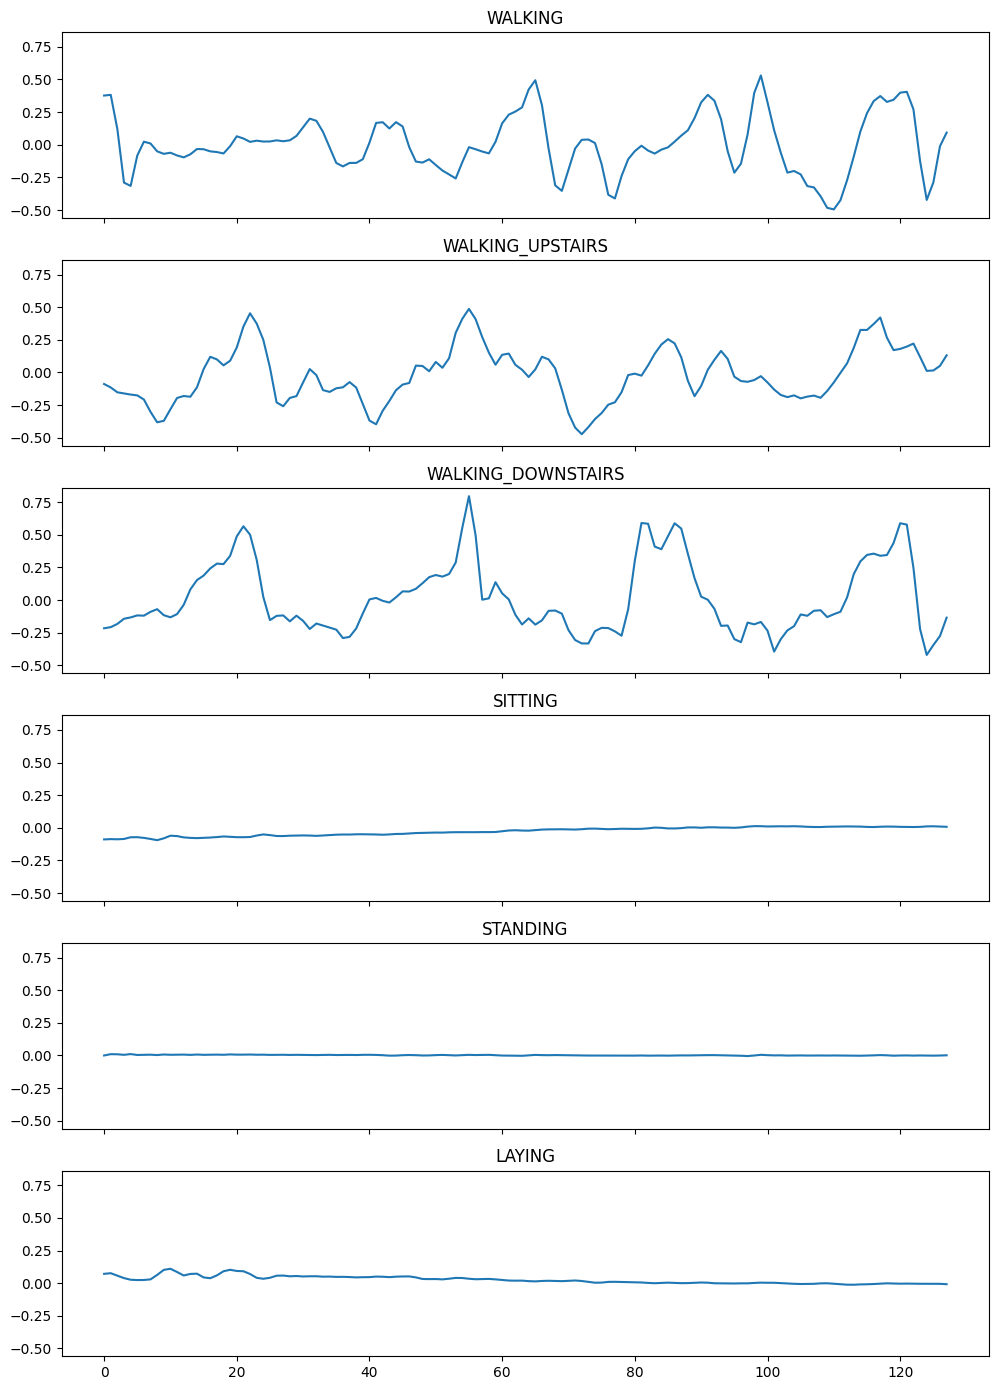

In [44]:
import matplotlib.pyplot as plt

activity_labels = {
    1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING', 5: 'STANDING', 6: 'LAYING'
}

fig, axes = plt.subplots(6, 1, figsize=(10, 14), sharex=True, sharey=True)
for i, (label_id, label_name) in enumerate(activity_labels.items()):
    idx = np.where(y_train == label_id)[0][0]
    axes[i].plot(raw_signals_train['body_acc_x'][idx])
    axes[i].set_title(label_name)
plt.tight_layout()
plt.show()

In [45]:
y_train_named = pd.Series(y_train).map(activity_labels)
print(y_train_named.value_counts())

LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


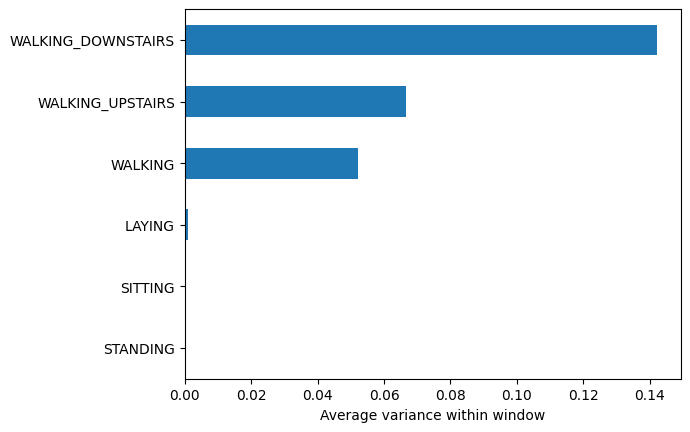

In [46]:
variances = {}
for label_id, label_name in activity_labels.items():
    idx = np.where(y_train == label_id)[0]
    variances[label_name] = raw_signals_train['body_acc_x'][idx].var(axis=1).mean()

pd.Series(variances).sort_values().plot(kind='barh')
plt.xlabel('Average variance within window')
plt.show()

In [47]:
def time_domain_features(window):
    centered = window - window.mean()  # remove DC offset before counting crossings
    return {
        'mean': np.mean(window),
        'std': np.std(window),
        'rms': np.sqrt(np.mean(window**2)),
        'min': np.min(window),
        'max': np.max(window),
        'zero_crossing_rate': ((centered[:-1] * centered[1:]) < 0).sum(),
    }

In [48]:
from scipy.signal import welch

def freq_domain_features(window, fs=50):
    freqs, psd = welch(window, fs=fs, nperseg=len(window))  # single-segment PSD, matches window length
    dominant_freq = freqs[np.argmax(psd)]
    spectral_energy = np.sum(psd**2)
    psd_norm = psd / psd.sum()
    spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
    return {
        'dominant_freq': dominant_freq,
        'spectral_energy': spectral_energy,
        'spectral_entropy': spectral_entropy,
    }

In [49]:
walking_idx = np.where(y_train == 1)[0][0]
sitting_idx = np.where(y_train == 4)[0][0]

walking_window = raw_signals_train['body_acc_x'][walking_idx]
sitting_window = raw_signals_train['body_acc_x'][sitting_idx]

print("=== WALKING ===")
print(time_domain_features(walking_window))
print(freq_domain_features(walking_window))

print("\n=== SITTING ===")
print(time_domain_features(sitting_window))
print(freq_domain_features(sitting_window))

=== WALKING ===
{'mean': np.float64(0.0009161932421875019), 'std': np.float64(0.21880245354852407), 'rms': np.float64(0.21880437173171624), 'min': np.float64(-0.495272), 'max': np.float64(0.5305173), 'zero_crossing_rate': np.int64(18)}
{'dominant_freq': np.float64(1.5625), 'spectral_energy': np.float64(0.001027992932236291), 'spectral_entropy': np.float64(4.0295068128602765)}

=== SITTING ===
{'mean': np.float64(-0.027423536419375), 'std': np.float64(0.0323846401659806), 'rms': np.float64(0.04243601381403337), 'min': np.float64(-0.09473339), 'max': np.float64(0.01269454), 'zero_crossing_rate': np.int64(1)}
{'dominant_freq': np.float64(0.390625), 'spectral_energy': np.float64(7.339077478763427e-07), 'spectral_entropy': np.float64(0.8912496735836032)}


In [50]:
def extract_features(raw_signals, feature_funcs):
    n_windows = raw_signals['body_acc_x'].shape[0]
    rows = []
    for i in range(n_windows):
        row = {}
        for channel_name, channel_data in raw_signals.items():
            window = channel_data[i]
            for func in feature_funcs:
                for feat_name, value in func(window).items():
                    row[f'{channel_name}_{feat_name}'] = value
        rows.append(row)
    return pd.DataFrame(rows)

feature_funcs = [time_domain_features, freq_domain_features]

X_train_feat = extract_features(raw_signals_train, feature_funcs)
X_test_feat = extract_features(raw_signals_test, feature_funcs)

print(X_train_feat.shape)  # expect (7352, 54) -> 6 channels x 9 features
print(X_test_feat.shape)
X_train_feat.head()

(7352, 54)
(2947, 54)


,body_acc_x_mean,body_acc_x_std,body_acc_x_rms,body_acc_x_min,body_acc_x_max,body_acc_x_zero_crossing_rate,body_acc_x_dominant_freq,body_acc_x_spectral_energy,body_acc_x_spectral_entropy,body_acc_y_mean,...,body_gyro_y_spectral_entropy,body_gyro_z_mean,body_gyro_z_std,body_gyro_z_rms,body_gyro_z_min,body_gyro_z_max,body_gyro_z_zero_crossing_rate,body_gyro_z_dominant_freq,body_gyro_z_spectral_energy,body_gyro_z_spectral_entropy
0,0.002269,0.002941,0.003714,-0.004294,0.010810,18,0.390625,2.563521e-11,4.187335,-0.001655,...,1.805320,0.009468,0.005943,0.011179,-0.006891,0.022859,19,0.390625,4.121020e-10,4.125855
1,0.000174,0.001981,0.001989,-0.006706,0.005251,35,5.468750,6.376314e-12,4.980422,0.000382,...,3.191305,0.006308,0.007431,0.009747,-0.009759,0.025133,17,0.390625,1.951150e-09,3.662556
2,0.000428,0.002908,0.002940,-0.010483,0.008167,36,5.468750,3.500418e-11,4.700587,-0.001222,...,4.315858,0.004335,0.008753,0.009768,-0.009759,0.028609,14,0.390625,9.145793e-09,3.769155
3,0.000329,0.002678,0.002698,-0.010483,0.008167,30,0.390625,7.693246e-12,4.667397,-0.004753,...,3.827496,-0.000352,0.008186,0.008194,-0.013223,0.028609,18,2.343750,2.735948e-10,4.101139
4,-0.000195,0.002015,0.002025,-0.006847,0.005650,31,4.296875,4.968126e-12,4.765275,0.000298,...,3.688254,-0.003957,0.008260,0.009159,-0.021141,0.019890,15,0.390625,3.371660e-09,3.637136


In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_train_feat, y_train)

y_pred = clf.predict(X_test_feat)
print(classification_report(y_test, y_pred, target_names=list(activity_labels.values())))

                    precision    recall  f1-score   support

           WALKING       0.93      0.93      0.93       496
  WALKING_UPSTAIRS       0.92      0.99      0.95       471
WALKING_DOWNSTAIRS       0.94      0.86      0.90       420
           SITTING       0.85      0.78      0.81       491
          STANDING       0.81      0.91      0.86       532
            LAYING       0.92      0.88      0.90       537

          accuracy                           0.89      2947
         macro avg       0.90      0.89      0.89      2947
      weighted avg       0.89      0.89      0.89      2947



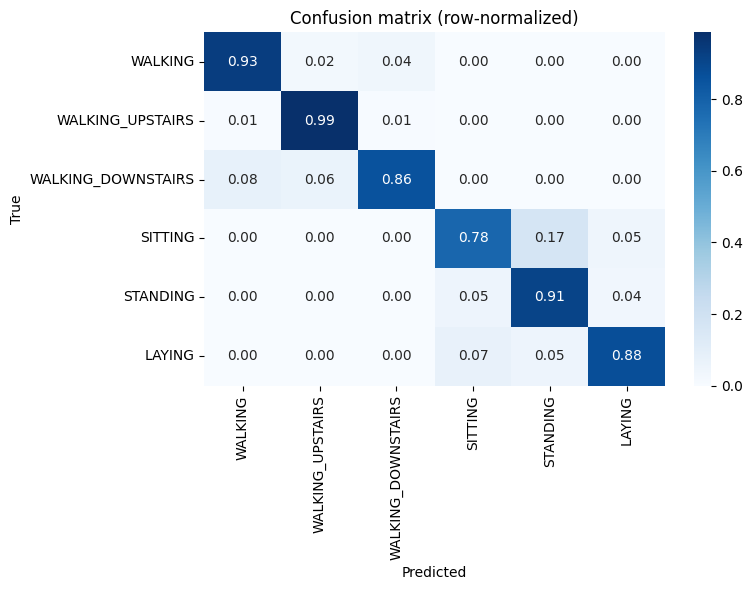

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, normalize='true')  # row-normalized: shows % of each true class
labels = list(activity_labels.values())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix (row-normalized)')
plt.tight_layout()
plt.show()

In [53]:
# total_acc includes the gravity component that body_acc has filtered out.
# Orientation (tilt) shows up as a DC offset in total_acc, which is exactly
# what distinguishes sitting from standing — body motion alone can't.

total_acc_files_train = {
    'total_acc_x': f'{base_path}/train/Inertial Signals/total_acc_x_train.txt',
    'total_acc_y': f'{base_path}/train/Inertial Signals/total_acc_y_train.txt',
    'total_acc_z': f'{base_path}/train/Inertial Signals/total_acc_z_train.txt',
}
total_acc_files_test = {
    'total_acc_x': f'{base_path}/test/Inertial Signals/total_acc_x_test.txt',
    'total_acc_y': f'{base_path}/test/Inertial Signals/total_acc_y_test.txt',
    'total_acc_z': f'{base_path}/test/Inertial Signals/total_acc_z_test.txt',
}

raw_total_acc_train = {name: np.loadtxt(path) for name, path in total_acc_files_train.items()}
raw_total_acc_test = {name: np.loadtxt(path) for name, path in total_acc_files_test.items()}

print(raw_total_acc_train['total_acc_x'].shape)  # expect (7352, 128)

(7352, 128)


In [54]:
def gravity_features(wx, wy, wz):
    return {
        'grav_mean_x': wx.mean(), 'grav_mean_y': wy.mean(), 'grav_mean_z': wz.mean(),
        'grav_std_x': wx.std(), 'grav_std_y': wy.std(), 'grav_std_z': wz.std(),
    }

def safe_corr(a, b):
    if a.std() == 0 or b.std() == 0:
        return 0.0
    return np.corrcoef(a, b)[0, 1]

def axis_correlation_features(wx, wy, wz):
    return {
        'corr_xy': safe_corr(wx, wy),
        'corr_xz': safe_corr(wx, wz),
        'corr_yz': safe_corr(wy, wz),
    }

def extract_gravity_and_corr(raw_total_acc, raw_body_acc):
    n_windows = raw_total_acc['total_acc_x'].shape[0]
    rows = []
    for i in range(n_windows):
        row = {}
        row.update(gravity_features(
            raw_total_acc['total_acc_x'][i], raw_total_acc['total_acc_y'][i], raw_total_acc['total_acc_z'][i]
        ))
        row.update(axis_correlation_features(
            raw_body_acc['body_acc_x'][i], raw_body_acc['body_acc_y'][i], raw_body_acc['body_acc_z'][i]
        ))
        rows.append(row)
    return pd.DataFrame(rows)

extra_train = extract_gravity_and_corr(raw_total_acc_train, raw_signals_train)
extra_test = extract_gravity_and_corr(raw_total_acc_test, raw_signals_test)

print(extra_train.shape)  # expect (7352, 9)
extra_train.head()

(7352, 9)


,grav_mean_x,grav_mean_y,grav_mean_z,grav_std_x,grav_std_y,grav_std_z,corr_xy,corr_xz,corr_yz
0,1.019305,-0.124262,0.099732,0.001791,0.003270,0.003970,0.374934,0.433372,0.657736
1,1.019448,-0.122936,0.096939,0.001932,0.004930,0.004918,-0.011562,-0.071672,0.576627
2,1.019927,-0.124997,0.092897,0.002904,0.006460,0.006145,-0.121905,-0.179492,0.606037
3,1.020349,-0.130493,0.087654,0.002574,0.004029,0.004945,-0.301393,-0.360048,0.504970
4,1.020255,-0.130209,0.084999,0.001949,0.003876,0.003637,-0.152752,-0.188102,0.596386


In [55]:
X_train_full = pd.concat([X_train_feat.reset_index(drop=True), extra_train], axis=1)
X_test_full = pd.concat([X_test_feat.reset_index(drop=True), extra_test], axis=1)

print(X_train_full.shape)  # expect (7352, 63)

clf_v2 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf_v2.fit(X_train_full, y_train)

y_pred_v2 = clf_v2.predict(X_test_full)
print(classification_report(y_test, y_pred_v2, target_names=labels))

(7352, 63)
                    precision    recall  f1-score   support

           WALKING       0.94      0.96      0.95       496
  WALKING_UPSTAIRS       0.90      0.97      0.94       471
WALKING_DOWNSTAIRS       0.96      0.86      0.91       420
           SITTING       0.95      0.90      0.93       491
          STANDING       0.92      0.96      0.94       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.95      2947
         macro avg       0.95      0.94      0.94      2947
      weighted avg       0.95      0.95      0.94      2947



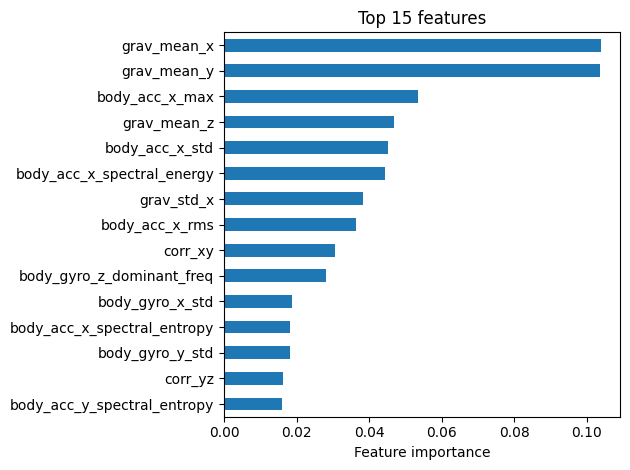

In [56]:
importances = pd.Series(clf_v2.feature_importances_, index=X_train_full.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh')
plt.xlabel('Feature importance')
plt.title('Top 15 features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

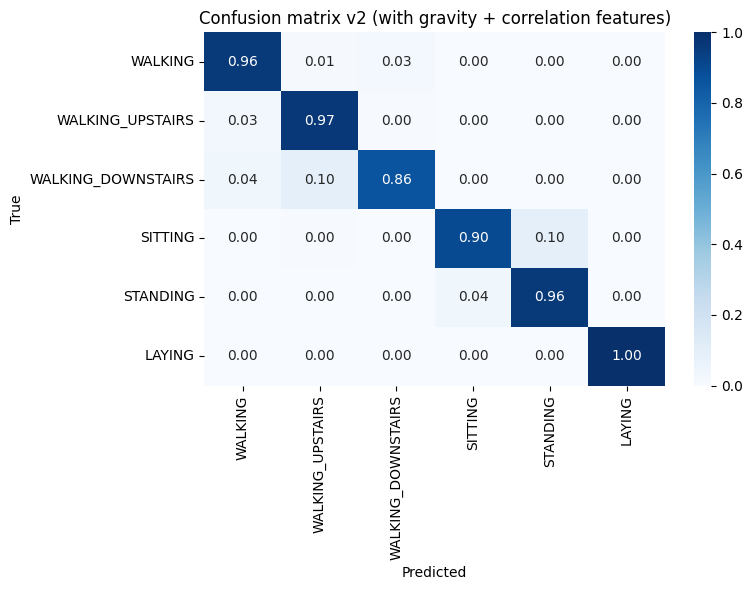

In [57]:
cm_v2 = confusion_matrix(y_test, y_pred_v2, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm_v2, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix v2 (with gravity + correlation features)')
plt.tight_layout()
plt.show()

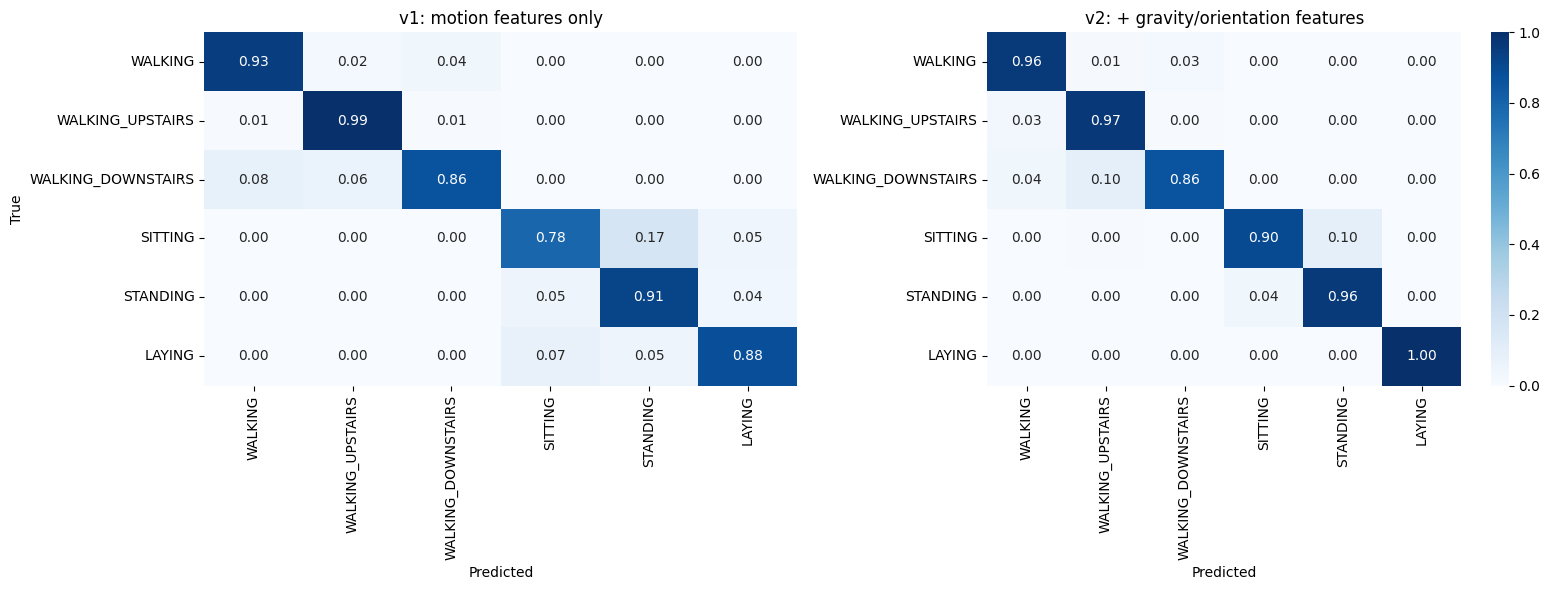

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0], cbar=False)
axes[0].set_title('v1: motion features only')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_v2, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('v2: + gravity/orientation features')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Use all 9 raw channels: 6 body signals + 3 total_acc (gravity-inclusive),
# since gravity is exactly what helped the classical model — fair to give
# the CNN the same information rather than a weaker input.
channel_order = ['body_acc_x', 'body_acc_y', 'body_acc_z',
                  'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
                  'total_acc_x', 'total_acc_y', 'total_acc_z']

def stack_channels(body_dict, total_dict):
    arrays = []
    for ch in channel_order:
        arrays.append(body_dict[ch] if ch in body_dict else total_dict[ch])
    # shape: (n_channels, n_windows, 128) -> transpose to (n_windows, n_channels, 128)
    return np.stack(arrays, axis=0).transpose(1, 0, 2)

X_train_raw = stack_channels(raw_signals_train, raw_total_acc_train)
X_test_raw = stack_channels(raw_signals_test, raw_total_acc_test)

print(X_train_raw.shape)  # expect (7352, 9, 128)
print(X_test_raw.shape)   # expect (2947, 9, 128)

(7352, 9, 128)
(2947, 9, 128)


In [60]:
# Standardize each channel independently using train statistics only —
# fitting on test data would leak information.
channel_mean = X_train_raw.mean(axis=(0, 2), keepdims=True)
channel_std = X_train_raw.std(axis=(0, 2), keepdims=True) + 1e-8

X_train_norm = (X_train_raw - channel_mean) / channel_std
X_test_norm = (X_test_raw - channel_mean) / channel_std

# Labels are 1-6, PyTorch CrossEntropyLoss expects 0-indexed
y_train_idx = (y_train - 1).astype(np.int64)
y_test_idx = (y_test - 1).astype(np.int64)

print(X_train_norm.shape, y_train_idx.min(), y_train_idx.max())  # expect 0 5

(7352, 9, 128) 0 5


In [61]:
class HARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Hold out 15% of train as validation, stratified so class balance is preserved
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_norm, y_train_idx, test_size=0.15, random_state=42, stratify=y_train_idx
)

train_ds = HARDataset(X_tr, y_tr)
val_ds = HARDataset(X_val, y_val)
test_ds = HARDataset(X_test_norm, y_test_idx)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

print(len(train_ds), len(val_ds), len(test_ds))

6249 1103 2947


In [62]:
class HAR_CNN(nn.Module):
    def __init__(self, n_channels=9, n_classes=6):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)

        # input length 128 -> after two pools of stride 2 -> 32
        self.fc1 = nn.Linear(128 * 32, 128)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        # x shape: (batch, channels, timesteps)
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.flatten(1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HAR_CNN().to(device)
print(model)
print('Device:', device)

HAR_CNN(
  (conv1): Conv1d(9, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)
Device: cuda


In [63]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

n_epochs = 40
best_val_loss = float('inf')
patience, patience_counter = 6, 0
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_ds)

    model.eval()
    val_loss, correct = 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
    val_loss /= len(val_ds)
    val_acc = correct / len(val_ds)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1:2d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | val_acc {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_cnn.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

Epoch  1 | train_loss 0.3484 | val_loss 0.1179 | val_acc 0.9529
Epoch  2 | train_loss 0.1420 | val_loss 0.0993 | val_acc 0.9565
Epoch  3 | train_loss 0.1350 | val_loss 0.1044 | val_acc 0.9465
Epoch  4 | train_loss 0.1311 | val_loss 0.1124 | val_acc 0.9465
Epoch  5 | train_loss 0.1232 | val_loss 0.1016 | val_acc 0.9574
Epoch  6 | train_loss 0.1170 | val_loss 0.0922 | val_acc 0.9619
Epoch  7 | train_loss 0.1101 | val_loss 0.1133 | val_acc 0.9492
Epoch  8 | train_loss 0.1164 | val_loss 0.0939 | val_acc 0.9619
Epoch  9 | train_loss 0.1019 | val_loss 0.0856 | val_acc 0.9619
Epoch 10 | train_loss 0.1060 | val_loss 0.0887 | val_acc 0.9628
Epoch 11 | train_loss 0.1028 | val_loss 0.0897 | val_acc 0.9646
Epoch 12 | train_loss 0.1221 | val_loss 0.0989 | val_acc 0.9628
Epoch 13 | train_loss 0.1089 | val_loss 0.0878 | val_acc 0.9610
Epoch 14 | train_loss 0.1001 | val_loss 0.0851 | val_acc 0.9565
Epoch 15 | train_loss 0.0981 | val_loss 0.0821 | val_acc 0.9628
Epoch 16 | train_loss 0.1002 | val_loss 

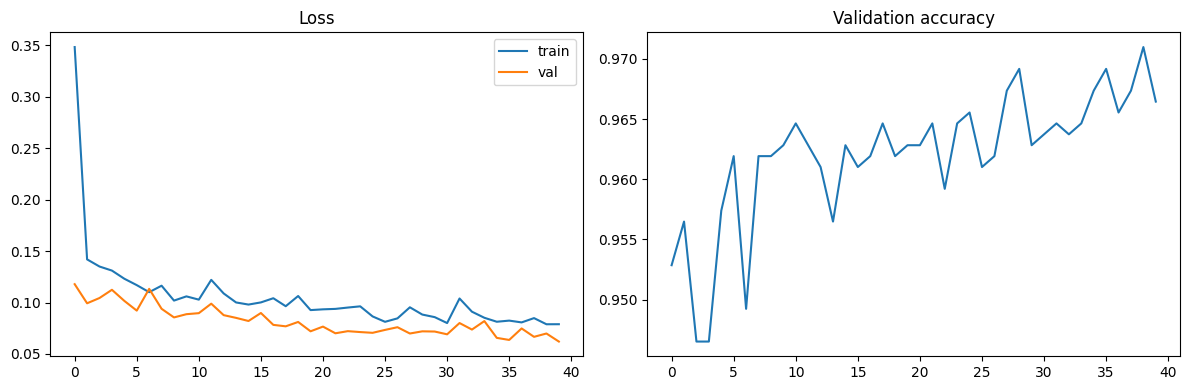

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history['val_acc'])
axes[1].set_title('Validation accuracy')
plt.tight_layout()
plt.show()

In [65]:
model.load_state_dict(torch.load('best_cnn.pt'))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model(xb)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

y_pred_cnn = np.array(all_preds) + 1  # back to 1-indexed to match your labels dict
y_true_cnn = np.array(all_true) + 1

print(classification_report(y_true_cnn, y_pred_cnn, target_names=labels))

                    precision    recall  f1-score   support

           WALKING       1.00      0.95      0.98       496
  WALKING_UPSTAIRS       0.99      0.93      0.96       471
WALKING_DOWNSTAIRS       0.89      1.00      0.94       420
           SITTING       0.86      0.84      0.85       491
          STANDING       0.86      0.87      0.87       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [66]:
class HAR_LSTM(nn.Module):
    def __init__(self, n_channels=9, hidden_size=128, n_layers=2, n_classes=6):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_channels, hidden_size=hidden_size, num_layers=n_layers,
            batch_first=True, dropout=0.3, bidirectional=True
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        pooled = out.mean(dim=1)  # average over all timesteps, both directions
        return self.fc(self.dropout(pooled))  # was: dropout(last_out) — leftover from the old version

model_lstm = HAR_LSTM().to(device)
print(model_lstm)

HAR_LSTM(
  (lstm): LSTM(9, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=6, bias=True)
)


In [67]:
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

n_epochs = 40
best_val_loss = float('inf')
patience, patience_counter = 6, 0
history_lstm = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(n_epochs):
    model_lstm.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_lstm.zero_grad()
        out = model_lstm(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer_lstm.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_ds)

    model_lstm.eval()
    val_loss, correct = 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model_lstm(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
    val_loss /= len(val_ds)
    val_acc = correct / len(val_ds)

    history_lstm['train_loss'].append(train_loss)
    history_lstm['val_loss'].append(val_loss)
    history_lstm['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1:2d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | val_acc {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_lstm.state_dict(), 'best_lstm.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

Epoch  1 | train_loss 0.7808 | val_loss 0.1838 | val_acc 0.9347
Epoch  2 | train_loss 0.1757 | val_loss 0.1683 | val_acc 0.9356
Epoch  3 | train_loss 0.1351 | val_loss 0.1126 | val_acc 0.9637
Epoch  4 | train_loss 0.1228 | val_loss 0.1119 | val_acc 0.9529
Epoch  5 | train_loss 0.1155 | val_loss 0.1120 | val_acc 0.9501
Epoch  6 | train_loss 0.1621 | val_loss 0.1179 | val_acc 0.9547
Epoch  7 | train_loss 0.1224 | val_loss 0.1154 | val_acc 0.9592
Epoch  8 | train_loss 0.1118 | val_loss 0.1024 | val_acc 0.9483
Epoch  9 | train_loss 0.1146 | val_loss 0.0987 | val_acc 0.9501
Epoch 10 | train_loss 0.1104 | val_loss 0.1083 | val_acc 0.9556
Epoch 11 | train_loss 0.1054 | val_loss 0.0950 | val_acc 0.9529
Epoch 12 | train_loss 0.1123 | val_loss 0.0978 | val_acc 0.9646
Epoch 13 | train_loss 0.1046 | val_loss 0.0926 | val_acc 0.9637
Epoch 14 | train_loss 0.1072 | val_loss 0.0935 | val_acc 0.9619
Epoch 15 | train_loss 0.1146 | val_loss 0.1077 | val_acc 0.9637
Epoch 16 | train_loss 0.1146 | val_loss 

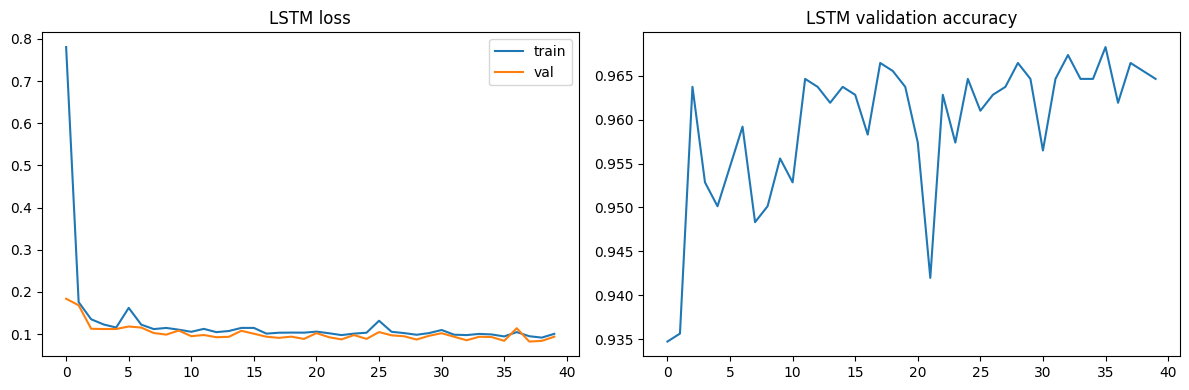

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_lstm['train_loss'], label='train')
axes[0].plot(history_lstm['val_loss'], label='val')
axes[0].set_title('LSTM loss')
axes[0].legend()
axes[1].plot(history_lstm['val_acc'])
axes[1].set_title('LSTM validation accuracy')
plt.tight_layout()
plt.show()

In [69]:
model_lstm.load_state_dict(torch.load('best_lstm.pt'))
model_lstm.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model_lstm(xb)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

y_pred_lstm = np.array(all_preds) + 1
y_true_lstm = np.array(all_true) + 1

print(classification_report(y_true_lstm, y_pred_lstm, target_names=labels))

                    precision    recall  f1-score   support

           WALKING       0.98      0.95      0.97       496
  WALKING_UPSTAIRS       0.97      0.96      0.96       471
WALKING_DOWNSTAIRS       0.92      0.98      0.95       420
           SITTING       0.83      0.78      0.81       491
          STANDING       0.82      0.86      0.84       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



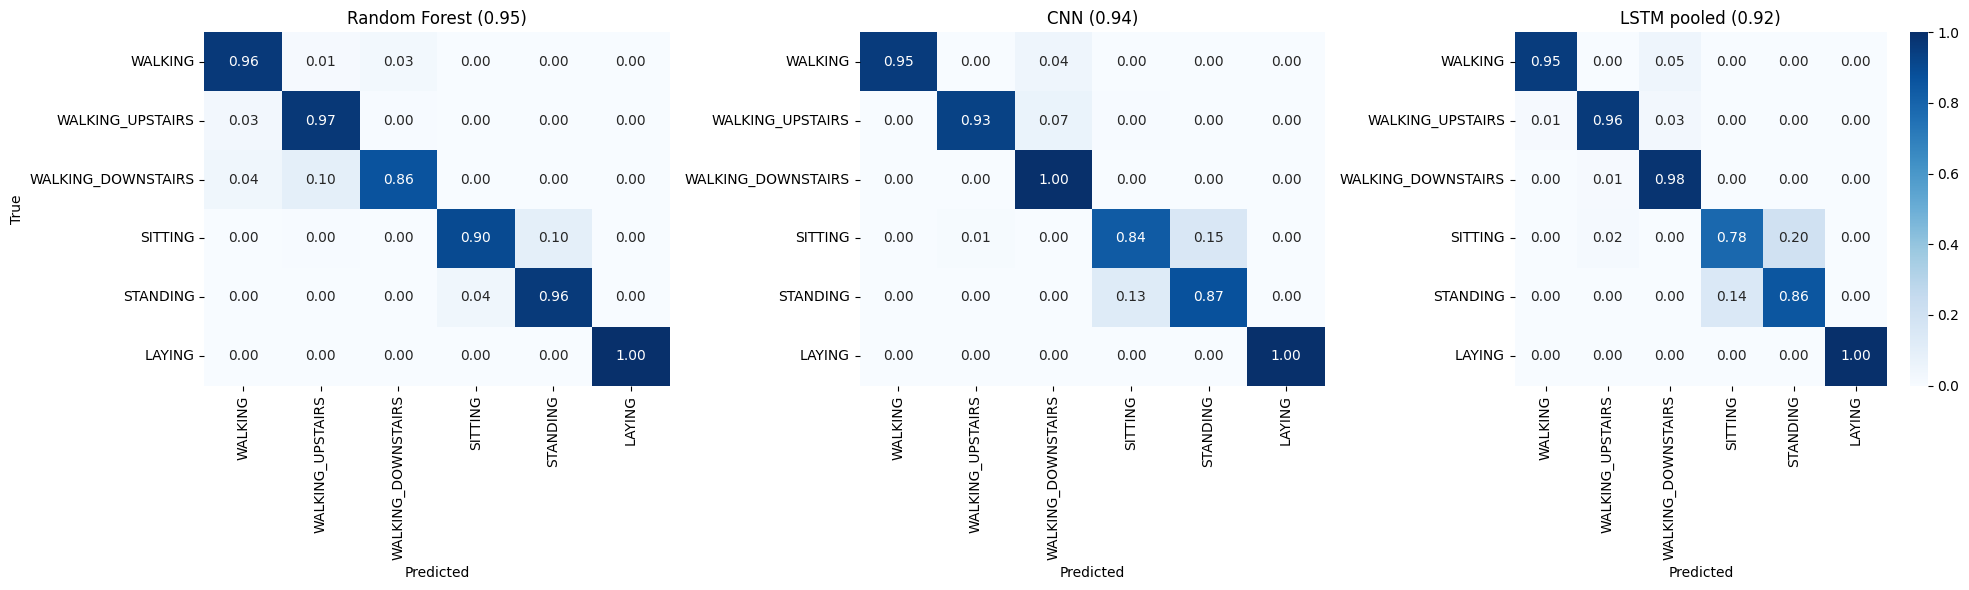

In [70]:
cm_rf = confusion_matrix(y_test, y_pred_v2, normalize='true')
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn, normalize='true')
cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm, normalize='true')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, cm_i, title in zip(axes, [cm_rf, cm_cnn, cm_lstm],
                            ['Random Forest (0.95)', 'CNN (0.94)', 'LSTM pooled (0.92)']):
    sns.heatmap(cm_i, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels,
                ax=ax, cbar=(ax==axes[-1]))
    ax.set_title(title)
    ax.set_xlabel('Predicted')
axes[0].set_ylabel('True')
plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [71]:
from sklearn.metrics import f1_score

summary = pd.DataFrame({
    'Model': ['Random Forest (engineered features)', 'CNN (raw signals)', 'LSTM pooled (raw signals)'],
    'Accuracy': [
        (y_pred_v2 == y_test).mean(),
        (y_pred_cnn == y_true_cnn).mean(),
        (y_pred_lstm == y_true_lstm).mean(),
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_v2, average='macro'),
        f1_score(y_true_cnn, y_pred_cnn, average='macro'),
        f1_score(y_true_lstm, y_pred_lstm, average='macro'),
    ],
    'Sitting F1': [
        f1_score(y_test, y_pred_v2, labels=[4], average='macro'),
        f1_score(y_true_cnn, y_pred_cnn, labels=[4], average='macro'),
        f1_score(y_true_lstm, y_pred_lstm, labels=[4], average='macro'),
    ],
    'Standing F1': [
        f1_score(y_test, y_pred_v2, labels=[5], average='macro'),
        f1_score(y_true_cnn, y_pred_cnn, labels=[5], average='macro'),
        f1_score(y_true_lstm, y_pred_lstm, labels=[5], average='macro'),
    ],
})
summary = summary.round(3)
summary.to_csv('/kaggle/working/model_comparison_summary.csv', index=False)
summary

,Model,Accuracy,Macro F1,Sitting F1,Standing F1
0,Random Forest (engineered features),0.945,0.943,0.926,0.937
1,CNN (raw signals),0.931,0.931,0.845,0.867
2,LSTM pooled (raw signals),0.920,0.920,0.807,0.838


In [72]:
import pickle

# Save the RF model (your best performer) plus everything needed to
# reproduce feature extraction on new raw input at inference time
with open('/kaggle/working/har_rf_model.pkl', 'wb') as f:
    pickle.dump(clf_v2, f)

# You need the exact feature column order the model was trained on,
# or a new input's features will silently misalign with the wrong weights
with open('/kaggle/working/feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X_train_full.columns), f)

print("Saved model with", len(X_train_full.columns), "features")

Saved model with 63 features


In [73]:
import json
import os

os.makedirs('/kaggle/working/samples', exist_ok=True)

for label_id, label_name in activity_labels.items():
    idx = np.where(y_test == label_id)[0][0]
    window = {
        'body_acc_x': raw_signals_test['body_acc_x'][idx].tolist(),
        'body_acc_y': raw_signals_test['body_acc_y'][idx].tolist(),
        'body_acc_z': raw_signals_test['body_acc_z'][idx].tolist(),
        'body_gyro_x': raw_signals_test['body_gyro_x'][idx].tolist(),
        'body_gyro_y': raw_signals_test['body_gyro_y'][idx].tolist(),
        'body_gyro_z': raw_signals_test['body_gyro_z'][idx].tolist(),
        'total_acc_x': raw_total_acc_test['total_acc_x'][idx].tolist(),
        'total_acc_y': raw_total_acc_test['total_acc_y'][idx].tolist(),
        'total_acc_z': raw_total_acc_test['total_acc_z'][idx].tolist(),
    }
    with open(f'/kaggle/working/samples/{label_name.lower()}.json', 'w') as f:
        json.dump(window, f)

print("Saved:", os.listdir('/kaggle/working/samples'))

Saved: ['laying.json', 'sitting.json', 'walking.json', 'standing.json', 'walking_upstairs.json', 'walking_downstairs.json']


In [74]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Combine your already-computed feature sets and labels across train+test,
# since LOSO re-splits by subject, not by the dataset's original train/test division
X_all = pd.concat([X_train_full, X_test_full], axis=0).reset_index(drop=True)
y_all = np.concatenate([y_train, y_test])
subjects_all = np.concatenate([subject_train, subject_test])

print(X_all.shape, y_all.shape, subjects_all.shape)
print("Unique subjects:", len(np.unique(subjects_all)))  # expect 30

(10299, 63) (10299,) (10299,)
Unique subjects: 30


In [75]:
unique_subjects = np.unique(subjects_all)
fold_results = []
all_fold_preds = []
all_fold_true = []

for test_subject in unique_subjects:
    train_mask = subjects_all != test_subject
    test_mask = subjects_all == test_subject

    X_tr, X_te = X_all[train_mask], X_all[test_mask]
    y_tr, y_te = y_all[train_mask], y_all[test_mask]

    clf_fold = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    clf_fold.fit(X_tr, y_tr)
    y_pred_fold = clf_fold.predict(X_te)

    acc = accuracy_score(y_te, y_pred_fold)
    f1 = f1_score(y_te, y_pred_fold, average='macro')

    fold_results.append({'subject': int(test_subject), 'accuracy': acc, 'macro_f1': f1, 'n_samples': test_mask.sum()})
    all_fold_preds.extend(y_pred_fold)
    all_fold_true.extend(y_te)

    print(f"Subject {int(test_subject):>2} | n={test_mask.sum():>3} | accuracy={acc:.3f} | macro_f1={f1:.3f}")

Subject  1 | n=347 | accuracy=0.983 | macro_f1=0.980
Subject  2 | n=302 | accuracy=0.950 | macro_f1=0.948
Subject  3 | n=341 | accuracy=0.988 | macro_f1=0.988
Subject  4 | n=317 | accuracy=0.972 | macro_f1=0.972
Subject  5 | n=302 | accuracy=0.887 | macro_f1=0.885
Subject  6 | n=325 | accuracy=0.846 | macro_f1=0.820
Subject  7 | n=308 | accuracy=0.938 | macro_f1=0.937
Subject  8 | n=281 | accuracy=0.911 | macro_f1=0.908
Subject  9 | n=288 | accuracy=0.927 | macro_f1=0.926
Subject 10 | n=294 | accuracy=0.952 | macro_f1=0.951
Subject 11 | n=316 | accuracy=0.994 | macro_f1=0.994
Subject 12 | n=320 | accuracy=0.950 | macro_f1=0.946
Subject 13 | n=327 | accuracy=0.963 | macro_f1=0.962
Subject 14 | n=323 | accuracy=0.817 | macro_f1=0.799
Subject 15 | n=328 | accuracy=0.991 | macro_f1=0.990
Subject 16 | n=366 | accuracy=0.913 | macro_f1=0.927
Subject 17 | n=368 | accuracy=0.981 | macro_f1=0.979
Subject 18 | n=364 | accuracy=0.909 | macro_f1=0.893
Subject 19 | n=360 | accuracy=0.869 | macro_f1

In [76]:
results_df = pd.DataFrame(fold_results)
print(f"\nMean accuracy: {results_df['accuracy'].mean():.4f} ± {results_df['accuracy'].std():.4f}")
print(f"Mean macro F1: {results_df['macro_f1'].mean():.4f} ± {results_df['macro_f1'].std():.4f}")
print(f"\nWorst subject: {results_df.loc[results_df['accuracy'].idxmin(), 'subject']} (acc={results_df['accuracy'].min():.3f})")
print(f"Best subject: {results_df.loc[results_df['accuracy'].idxmax(), 'subject']} (acc={results_df['accuracy'].max():.3f})")

results_df.sort_values('accuracy')


Mean accuracy: 0.9393 ± 0.0525
Mean macro F1: 0.9344 ± 0.0610

Worst subject: 14 (acc=0.817)
Best subject: 24 (acc=1.000)


,subject,accuracy,macro_f1,n_samples
13,14,0.817337,0.798759,323
24,25,0.828851,0.808318,409
5,6,0.846154,0.820300,325
21,22,0.862928,0.816558,321
18,19,0.869444,0.846541,360
4,5,0.887417,0.884601,302
17,18,0.909341,0.892615,364
7,8,0.911032,0.908158,281
15,16,0.912568,0.927354,366
27,28,0.916230,0.924311,382


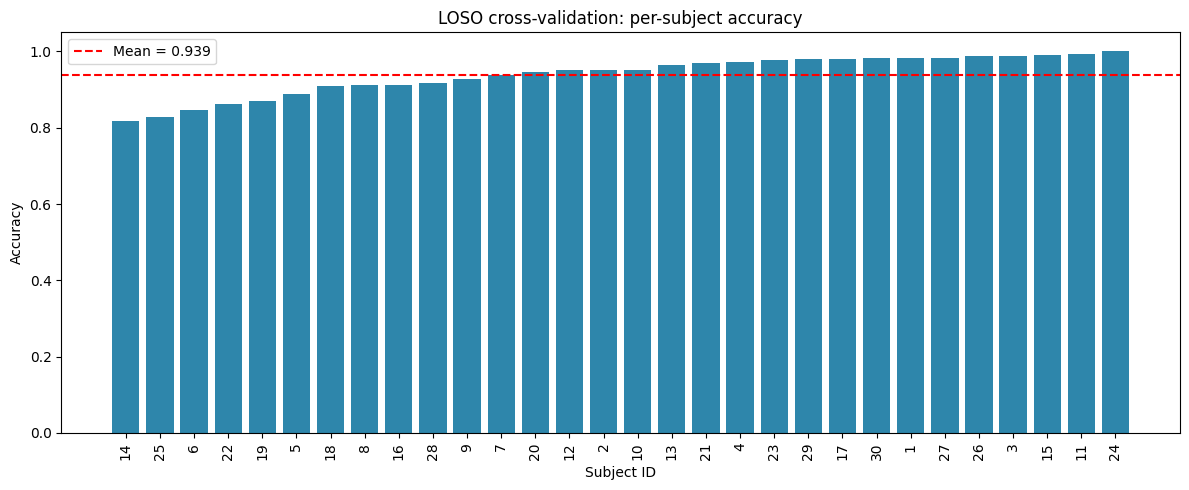

In [81]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
results_df_sorted = results_df.sort_values('accuracy')
ax.bar(results_df_sorted['subject'].astype(str), results_df_sorted['accuracy'], color='#2E86AB')
ax.axhline(results_df['accuracy'].mean(), color='red', linestyle='--', label=f"Mean = {results_df['accuracy'].mean():.3f}")
ax.set_xlabel('Subject ID')
ax.set_ylabel('Accuracy')
ax.set_title('LOSO cross-validation: per-subject accuracy')
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('/kaggle/working/loso_per_subject_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

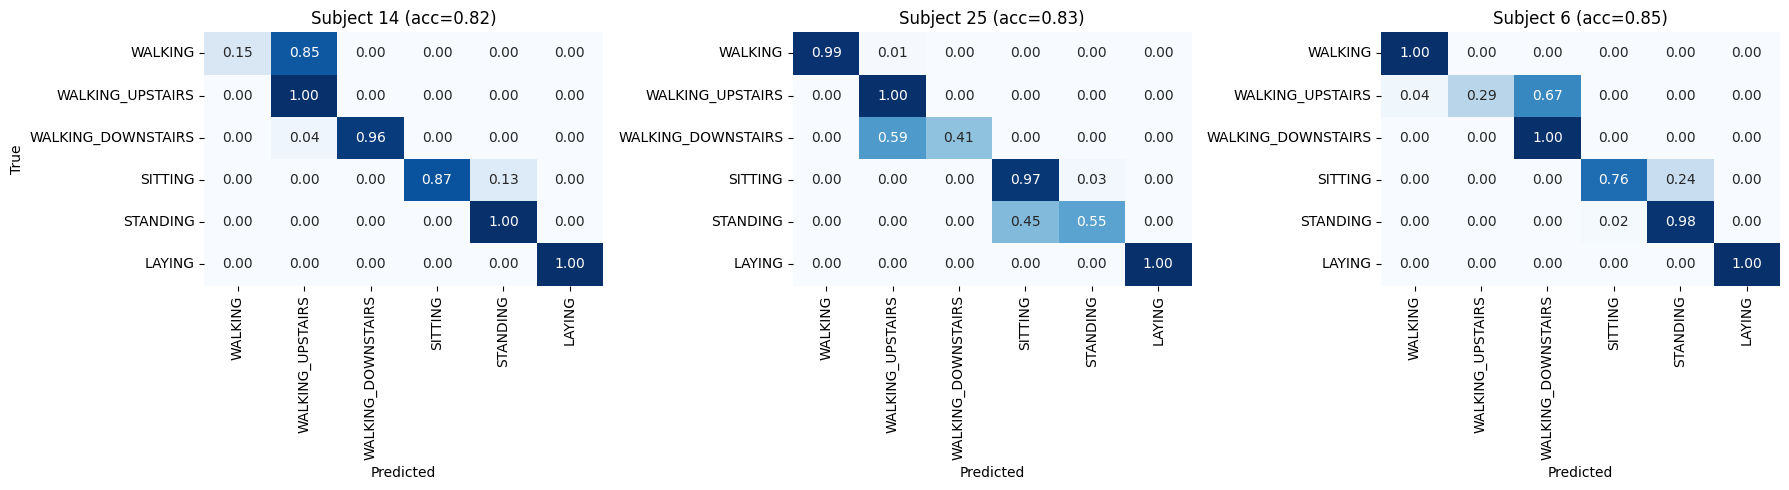

In [78]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

worst_subjects = [14, 25, 6]  # your three lowest-accuracy subjects

fig, axes = plt.subplots(1, len(worst_subjects), figsize=(18, 5))

for ax, subj in zip(axes, worst_subjects):
    train_mask = subjects_all != subj
    test_mask = subjects_all == subj

    X_tr, X_te = X_all[train_mask], X_all[test_mask]
    y_tr, y_te = y_all[train_mask], y_all[test_mask]

    clf_temp = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    clf_temp.fit(X_tr, y_tr)
    y_pred_temp = clf_temp.predict(X_te)

    cm = confusion_matrix(y_te, y_pred_temp, labels=list(activity_labels.keys()), normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
    ax.set_title(f'Subject {subj} (acc={accuracy_score(y_te, y_pred_temp):.2f})')
    ax.set_xlabel('Predicted')

axes[0].set_ylabel('True')
plt.tight_layout()
plt.show()